In [253]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 
from sklearn import tree 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import r2_score, root_mean_squared_error 
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import OneHotEncoder  
from sklearn.model_selection import GridSearchCV, cross_val_score 
from sklearn.pipeline import Pipeline 
from sklearn import ensemble 

In [ ]:
data = pd.read_csv("../Data/Dataset.csv") 
data.head() 

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,570000


Insights

In [255]:
print(data.info()) 

<class 'pandas.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  str    
 2   brand              15411 non-null  str    
 3   model              15411 non-null  str    
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  str    
 7   fuel_type          15411 non-null  str    
 8   transmission_type  15411 non-null  str    
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  selling_price      15411 non-null  int64  
dtypes: float64(1), int64(5), str(6)
memory usage: 1.4 MB
None


In [256]:
## Checking duplicated rows
check = data.duplicated()
check.sum()

np.int64(0)

In [257]:
numeric = data.select_dtypes(include='number')
metric = numeric.corrwith(data['selling_price'])
data[numeric.columns]
print(metric) 

Unnamed: 0       0.030523
vehicle_age     -0.241851
km_driven       -0.080030
mileage         -0.305549
engine           0.585844
selling_price    1.000000
dtype: float64


Categorical Columns

In [258]:
cat = data.select_dtypes(exclude='number')
print(cat['seller_type'].value_counts())
print(cat['transmission_type'].value_counts())
print(cat['fuel_type'].value_counts())

seller_type
Dealer              9539
Individual          5699
Trustmark Dealer     173
Name: count, dtype: int64
transmission_type
Manual       12225
Automatic     3186
Name: count, dtype: int64
fuel_type
Petrol      7643
Diesel      7419
CNG          301
LPG           44
Electric       4
Name: count, dtype: int64


<BarContainer object of 5 artists>

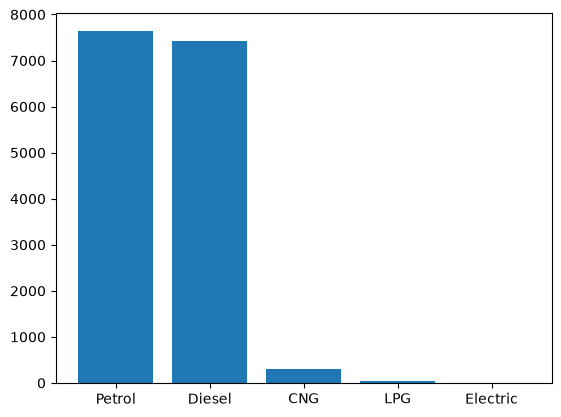

In [259]:
## fuel_type
fuel = data['fuel_type'].value_counts()
plt.bar(fuel.index, fuel.values)

There are very few cars with the fuel type of CNG, LPG and Electric.

<BarContainer object of 2 artists>

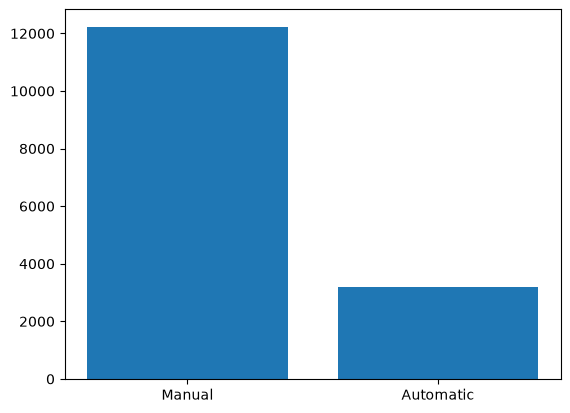

In [260]:
## transmission
trans = data['transmission_type'].value_counts()
plt.bar(trans.index, trans.values)

<BarContainer object of 3 artists>

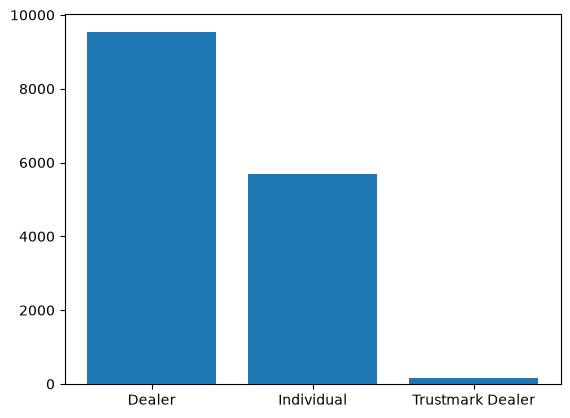

In [261]:
## Seller 
seller = data['seller_type'].value_counts()
plt.bar(seller.index, seller.values)

Cars with the seller type of Trustmark Dealer are very few.

Removing Vehicles with Electric fuel_type bcz they are very less in numbers:

In [262]:
rows = data.loc[data['fuel_type'] == 'Electric']
rows_index = rows.index 
data.drop(rows_index, axis = 0, inplace = True)

In [263]:
data['engine'].value_counts()
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(data['engine'].value_counts())

engine
1197    2436
1248    1668
998     1174
1498    1095
2179     669
1497     662
796      501
1199     469
1396     465
1198     437
1582     423
2494     342
1995     307
1086     288
1598     263
1591     255
1196     230
1373     229
999      228
2523     215
1461     213
799      207
1968     196
2143     155
1399     154
2393     140
2755     127
2982     123
2993     119
1493     104
1462     100
1997      95
1120      93
1798      85
1061      76
2987      73
1298      64
1799      59
2498      55
1956      54
1499      54
1186      48
1047      46
2967      41
1496      40
1998      39
1999      35
1796      32
3198      25
1194      22
1368      21
1991      21
2354      19
1599      17
2499      15
2148      15
3498      15
2694      13
2487      13
1451      12
1950      11
2979      11
1797      11
1969      10
2497      10
1896      10
1984       9
2609       9
793        9
1353       8
1395       8
2953       8
2198       8
2996       8
2400       7
2362       5
2495 

In [264]:
engine_cc_map = {
    793: 800,
    796: 800,
    799: 800,
    998: 1000,
    999: 1000,
    1047: 1050,
    1061: 1100,
    1086: 1100,
    1120: 1100,
    1186: 1200,
    1194: 1200,
    1196: 1200,
    1197: 1200,
    1198: 1200,
    1199: 1200,
    1248: 1250,
    1298: 1300,
    1330: 1300,
    1343: 1350,
    1353: 1350,
    1368: 1400,
    1373: 1400,
    1395: 1400,
    1396: 1400,
    1399: 1400,
    1451: 1450,
    1461: 1500,
    1462: 1500,
    1493: 1500,
    1496: 1500,
    1497: 1500,
    1498: 1500,
    1499: 1500,
    1582: 1600,
    1590: 1600,
    1591: 1600,
    1597: 1600,
    1598: 1600,
    1599: 1600,
    1668: 1700,
    1781: 1800,
    1796: 1800,
    1797: 1800,
    1798: 1800,
    1799: 1800,
    1896: 1900,
    1950: 1950,
    1956: 2000,
    1968: 2000,
    1969: 2000,
    1984: 2000,
    1985: 2000,
    1991: 2000,
    1995: 2000,
    1997: 2000,
    1998: 2000,
    1999: 2000,
    2092: 2100,
    2143: 2100,
    2148: 2150,
    2157: 2200,
    2179: 2200,
    2198: 2200,
    2199: 2200,
    2354: 2350,
    2362: 2400,
    2393: 2400,
    2400: 2400,
    2436: 2400,
    2487: 2500,
    2494: 2500,
    2495: 2500,
    2497: 2500,
    2498: 2500,
    2499: 2500,
    2523: 2500,
    2596: 2600,
    2609: 2600,
    2694: 2700,
    2698: 2700,
    2755: 2800,
    2771: 2800,
    2773: 2800,
    2953: 3000,
    2956: 3000,
    2967: 3000,
    2979: 3000,
    2982: 3000,
    2987: 3000,
    2993: 3000,
    2995: 3000,
    2996: 3000,
    2997: 3000,
    2998: 3000,
    2999: 3000,
    3198: 3200,
    3456: 3500,
    3498: 3500,
    3597: 3600,
    3598: 3600,
    3604: 3600,
    3628: 3600,
    3855: 3900,
    4134: 4100,
    4163: 4200,
    4367: 4400,
    4395: 4400,
    4663: 4700,
    4806: 4800,
    5461: 5500,
    5998: 6000,
    6592: 6600
}


In [265]:
data['engine'] = data['engine'].map(engine_cc_map)

In [266]:
len(data['engine'].value_counts())

38

In [267]:
for i in data['engine'].unique():
    engine_check = data.loc[data['engine'] == i]
    print(f"engine {i}: {engine_check['model'].value_counts()}")

engine 800: model
Alto       501
KWID       150
RediGO      52
Celerio      9
redi-GO      5
Name: count, dtype: int64
engine 1200: model
i20            558
Grand          487
Swift Dzire    332
Swift          328
Baleno         280
i10            261
Polo           247
Amaze          197
Jazz           132
Eeco           125
Tiago          112
GO              85
Figo            84
Ignis           68
KUV             66
WR-V            46
Nexon           35
Vento           32
Wagon R         30
KUV100          27
Tigor           24
Aspire          23
Freestyle       20
Dzire VXI       17
XUV300          10
Glanza           8
Dzire ZXI        4
Dzire LXI        2
Aura             1
Altroz           1
Name: count, dtype: int64
engine 1000: model
Wagon R     613
Alto        275
Celerio     228
KWID        156
Venue        39
RediGO       23
Polo         17
Ecosport     14
S-Presso     13
Triber       12
Baleno        6
redi-GO       5
Vento         1
Name: count, dtype: int64
engine 1500: 

In [268]:
## Brands with multiple models: Lexus, Volvo, Porsche, Audi, Skoda, Mercedes-Benz, Tata, BMW, Ford, Toyota, 
## Mahindra, Honda, Hyundai, Maruti, Volkswagen(2), Jaguar(3), Datsun(3), Renault(3) 

## Brands with one or two models: Mini(1), Nissan(2), MG(1), Kia(2),  Land Rover(1), 
## Maserati, ISUZU/ Isuzu, Ferrari, Mercedes-AMG, Rolls-Royce, Force, Bentley, 

checkk = data.loc[data['brand'] == 'Mercedes-Benz']
c = checkk['model'].value_counts()
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(c)

model
E-Class     125
C-Class     118
S-Class      37
GL-Class     36
GLS          12
CLS           9
Name: count, dtype: int64

In [269]:
## Removing those brands that contain very few training examples.
rows_to_drop_model = data[data['brand'].isin(["Mini","Nissan","MG","Kia","Land Rover","Maserati","Isuzu","ISUZU","Ferrari","Mercedes-AMG","Rolls-Royce","Force","Bentley","Lexus"])].index
data = data.drop(rows_to_drop_model, axis = 0)
print(rows_to_drop_model)
rows_to_drop_ele = data[data['fuel_type'] == 'Electric'].index 
data = data.drop(rows_to_drop_ele, axis = 0)
print(rows_to_drop_ele)

Index([   12,    80,   140,   156,   240,   285,   286,   318,   321,   363,
       ...
       14306, 14474, 14487, 14544, 14701, 14725, 14780, 14839, 15333, 15392],
      dtype='int64', length=159)
Index([], dtype='int64')


In [270]:
c = data['model'].value_counts()
count = 0
rows = []
for ind, val in zip(c.index, c):
    if val < 20: 
        print(f"Name: {ind}, value: {val}")
        count += 1
        rows.append(ind)
print(rows)        

Name: 6, value: 18
Name: Dzire VXI, value: 17
Name: Yaris, value: 17
Name: Cayenne, value: 16
Name: XUV300, value: 15
Name: S-Presso, value: 13
Name: Triber, value: 12
Name: GLS, value: 12
Name: Tucson, value: 10
Name: redi-GO, value: 10
Name: CLS, value: 9
Name: Glanza, value: 8
Name: XL6, value: 7
Name: XC, value: 7
Name: Z4, value: 6
Name: X4, value: 6
Name: A8, value: 6
Name: XC60, value: 5
Name: S90, value: 4
Name: Dzire ZXI, value: 4
Name: XC90, value: 4
Name: XE, value: 4
Name: CR, value: 3
Name: F-PACE, value: 3
Name: Panamera, value: 3
Name: Alturas, value: 3
Name: Wrangler, value: 2
Name: Dzire LXI, value: 2
Name: Macan, value: 2
Name: Aura, value: 1
Name: Altroz, value: 1
['6', 'Dzire VXI', 'Yaris', 'Cayenne', 'XUV300', 'S-Presso', 'Triber', 'GLS', 'Tucson', 'redi-GO', 'CLS', 'Glanza', 'XL6', 'XC', 'Z4', 'X4', 'A8', 'XC60', 'S90', 'Dzire ZXI', 'XC90', 'XE', 'CR', 'F-PACE', 'Panamera', 'Alturas', 'Wrangler', 'Dzire LXI', 'Macan', 'Aura', 'Altroz']


In [271]:
## removing those models that contain very few training examples
rows_to_drop = data[data['model'].isin(rows)].index
data = data.drop(rows_to_drop, axis = 0)

In [272]:
## Dropping columns.
data.drop(columns = ["Unnamed: 0","car_name"], inplace = True) 

In [273]:
data.head()

,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,selling_price
0,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,800,120000
1,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1200,550000
2,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1200,215000
3,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,1000,226000
4,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1500,570000


Numerical Columns

In [274]:
numeric = data.select_dtypes(include='number')
stat = pd.DataFrame({
    "mean":numeric.mean(),
    "median":numeric.median(),
    "skew":numeric.skew(),
    "max":numeric.max(),
    "min":numeric.min()
})
stat 

,mean,median,skew,max,min
vehicle_age,6.085298,6.0,0.844388,29.00,0.00
km_driven,56168.999268,50000.0,28.405372,3800000.00,100.00
mileage,19.791165,19.7,0.124449,33.54,7.81
engine,1476.624717,1250.0,1.489023,5500.00,800.00
selling_price,720164.061460,550000.0,4.688779,13000000.00,40000.00


Km_driven

lower: -30862.125, upper: 131436.875


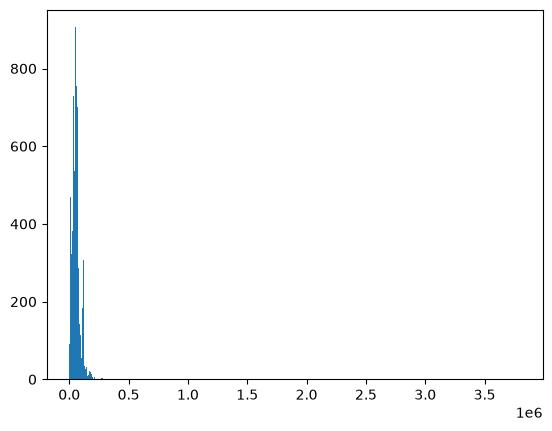

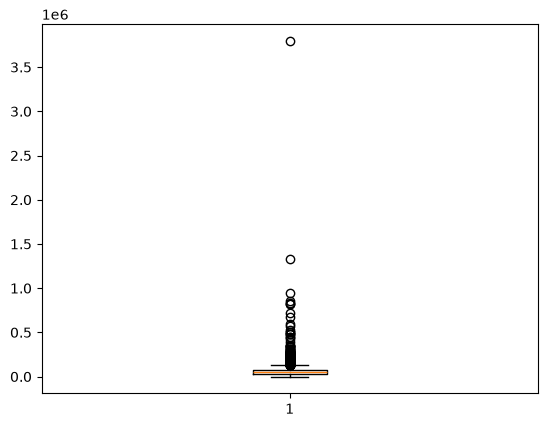

In [275]:

def IQRR(x):
    Q1 = data[x].quantile(0.25)
    Q3 = data[x].quantile(0.75)
    IQR = Q3 - Q1 
    Lo = Q1 - 1.5 * IQR 
    Up = Q3 + 1.5 * IQR 
    check = data.loc[(data[x] < Lo )| (data[x] > Up)]
    return Lo, Up, check
lower, upper, rows = IQRR('km_driven')
print(f"lower: {lower}, upper: {upper}")
# check = data[data['km_driven'] > 400000]
# check
plt.hist(data['km_driven'], bins='fd')
plt.show()
plt.boxplot(data['km_driven'])
plt.show() 

In [276]:
indmax = data.loc[data['km_driven'] > 1000000]
data.drop(indmax.index, axis = 0, inplace = True)
indmin = data.loc[data['km_driven'] < 1000]

There are only two cars with km_driven greater than 1000000. That is why these rows are removed

Mileage

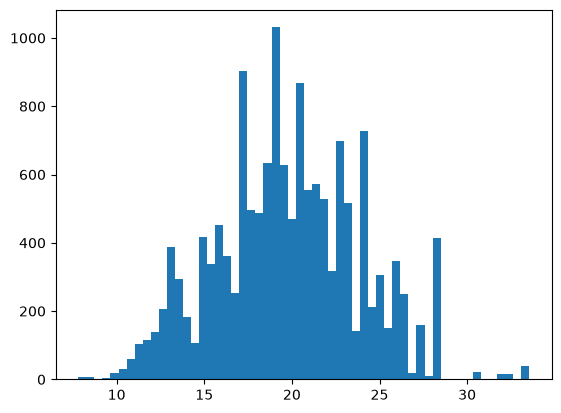

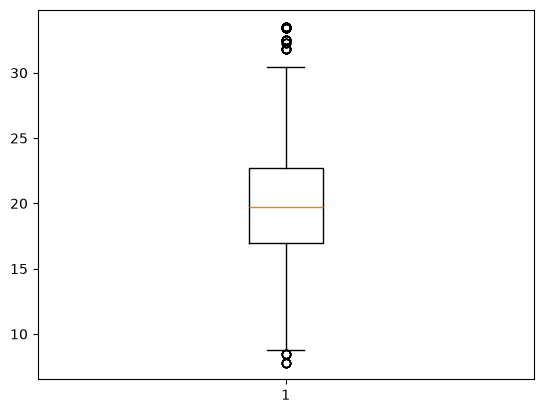

lower: -30862.125, upper: 31.25


,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,selling_price
169,Maruti,Wagon R,3,52000,Dealer,CNG,Manual,33.54,1000,435000
182,Maruti,Wagon R,8,64000,Dealer,CNG,Manual,33.54,1000,270000
317,Maruti,Celerio,3,28000,Dealer,CNG,Manual,31.79,1000,455000
480,Maruti,Alto,5,42000,Dealer,CNG,Manual,33.44,800,260000
693,Maruti,Wagon R,8,67000,Dealer,CNG,Manual,32.52,1000,260000
...,...,...,...,...,...,...,...,...,...,...
14334,Maruti,Alto,3,58000,Dealer,CNG,Manual,33.44,800,350000
14853,Maruti,Wagon R,3,57000,Dealer,CNG,Manual,32.52,1000,435000
14932,Maruti,Celerio,2,50000,Individual,CNG,Manual,31.79,1000,390000
15226,Maruti,Wagon R,5,74844,Dealer,CNG,Manual,33.54,1000,390000


In [277]:
## mileage
Lower, upper, check = IQRR('mileage')
plt.hist(data['mileage'], bins = 'fd')
plt.show()
plt.boxplot(data['mileage'])
plt.show()
print(f'lower: {lower}, upper: {upper}')
check 

Vehicle_age

lower: -2.0, upper: 14.0


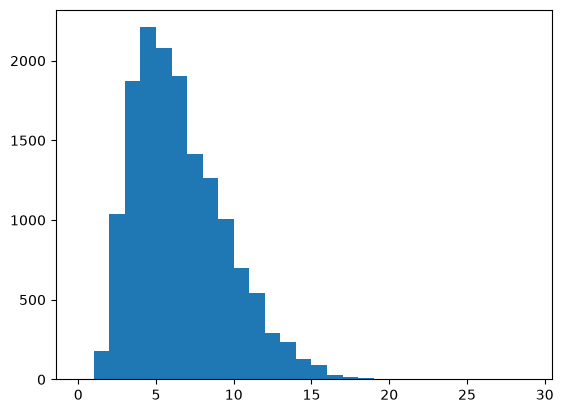

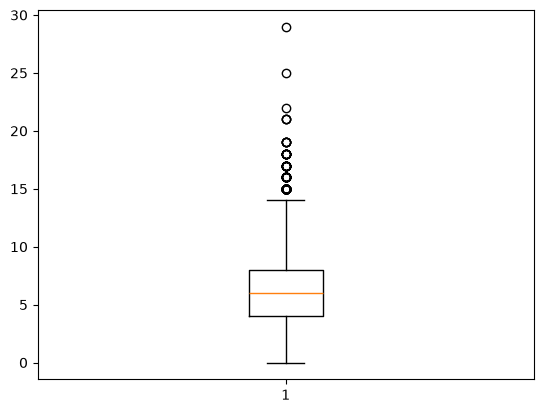

LowerBound: -2.0, UpperBound: 14.0


,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,selling_price
65,Maruti,Wagon R,15,37000,Dealer,Petrol,Manual,14.00,1100,155000
161,Mahindra,Bolero,15,120000,Individual,Diesel,Manual,13.60,2500,150000
245,Maruti,Alto,16,70000,Individual,Petrol,Manual,19.70,800,85000
299,Maruti,Wagon R,15,70000,Individual,Petrol,Manual,18.90,1000,200000
344,Maruti,Alto,16,5000,Individual,Petrol,Manual,19.70,800,95000
...,...,...,...,...,...,...,...,...,...,...
15019,Honda,Civic,15,100000,Individual,Petrol,Manual,13.50,1800,120000
15028,Mahindra,Scorpio,15,132087,Individual,Diesel,Manual,10.50,2200,396000
15162,Tata,Safari,15,70000,Individual,Diesel,Manual,13.93,3000,300000
15316,Maruti,Wagon R,15,60000,Individual,Petrol,Manual,18.90,1000,80000


In [278]:
## vehicle_age 
lower, upper, check = IQRR('vehicle_age')
print(f"lower: {lower}, upper: {upper}")
plt.hist(data['vehicle_age'], bins='fd')
plt.show()
plt.boxplot(data['vehicle_age'])
plt.show()
print(f"LowerBound: {lower}, UpperBound: {upper}")
check 

In [279]:
veh_min = data.loc[data['vehicle_age'] == 0]
data.drop(veh_min.index, axis = 0, inplace = True)

<class 'pandas.Series'>
Index: 15012 entries, 0 to 15410
Series name: selling_price
Non-Null Count  Dtype
--------------  -----
15012 non-null  int64
dtypes: int64(1)
memory usage: 234.6 KB


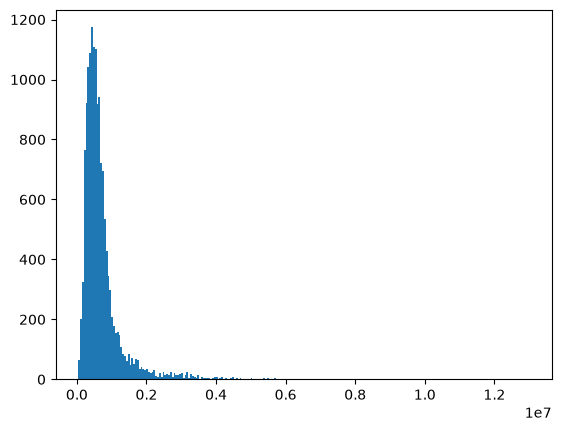

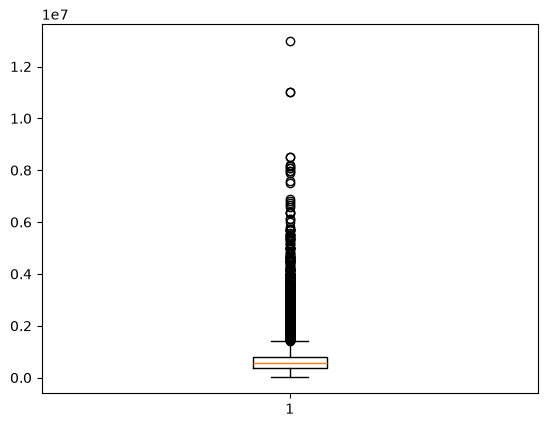

In [280]:
## Output Variable 
data['selling_price'].info()
plt.hist(data['selling_price'], bins = 'auto')
plt.show()
plt.boxplot(data['selling_price'])
plt.show()

In [281]:
print(f"max value: {data['selling_price'].max()}, mix value: {data['selling_price'].min()}, skewness: {data['selling_price'].skew()}")

max value: 13000000, mix value: 40000, skewness: 4.6957769617651985


So, the selling price is positively skewwed which means that most of its values lie on the left side (low values), but some values are very large. As a result a tail is formed on the right side.

In [282]:
Y_df = data['selling_price']
X_df = data.drop(columns = "selling_price") 

In [283]:
X_train, X_test, Y_train, Y_test = train_test_split(X_df, Y_df, random_state=11, shuffle=True, test_size=0.3)

In [284]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape) 

(10508, 9)
(4504, 9)
(10508,)
(4504,)


In [285]:
Col_trans = ColumnTransformer(
    transformers=[
        (
            'onehot1',
            OneHotEncoder(handle_unknown='ignore', sparse_output=False),
            ['brand','model','seller_type','fuel_type','transmission_type']
        ),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

In [286]:
Col_trans.fit(X_train)
Col_trans.set_output(transform='pandas')

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot1', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The ou

In [287]:
X_train_t = Col_trans.transform(X_train).astype('float64')
X_test_t = Col_trans.transform(X_test).astype('float64') 

In [288]:
model1 = ensemble.RandomForestRegressor(criterion='squared_error',random_state=11) 

In [289]:
model1.fit(X_train_t,Y_train) 

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",11
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [290]:
RF_pred_train = cross_val_score(model1, X=X_train_t, y=Y_train, cv = 5) 
RF_pred_train.mean()  

np.float64(0.9307481167524998)

In [291]:
for feature,importance in zip(X_train_t.columns, model1.feature_importances_): 
    print(f"feature: {feature}, Importance: {importance}")     

feature: brand_Audi, Importance: 0.0038282956360085533
feature: brand_BMW, Importance: 0.004847965339682682
feature: brand_Datsun, Importance: 0.00019314403040078589
feature: brand_Ford, Importance: 0.0014737209069720996
feature: brand_Honda, Importance: 0.0009620280923908741
feature: brand_Hyundai, Importance: 0.0015214812047076455
feature: brand_Jaguar, Importance: 0.0011923773789257693
feature: brand_Jeep, Importance: 0.0006277623790927829
feature: brand_Mahindra, Importance: 0.009732714724525523
feature: brand_Maruti, Importance: 9.160762846924338e-05
feature: brand_Mercedes-Benz, Importance: 0.0070724882545598645
feature: brand_Renault, Importance: 5.80153825180695e-05
feature: brand_Skoda, Importance: 0.0024942347915565305
feature: brand_Tata, Importance: 0.0006335102408352047
feature: brand_Toyota, Importance: 0.004164512027761812
feature: brand_Volkswagen, Importance: 0.00015365290838016858
feature: model_3, Importance: 0.0007152621288400552
feature: model_5, Importance: 0.0047

In [292]:
params = {
    "max_features":["sqrt",0.2,None],
    "max_depth":[None,20],
    "min_samples_leaf":[2,3],
    "n_estimators":[100,200,250]
}

In [293]:
grid = GridSearchCV(estimator=ensemble.RandomForestRegressor(random_state=11),param_grid=params,n_jobs=-1, verbose=2, cv = 5) 

In [294]:
grid.fit(X_train_t, Y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=11)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 20], 'max_features': ['sqrt', 0.2, ...], 'min_samples_leaf': [2, 3], 'n_estimators': [100, 200, ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_example

In [295]:
modelgrid = grid.best_estimator_    

In [296]:
for i, tree in enumerate(grid.best_estimator_):
    print(f"{i+1}: {tree.get_depth()}")    

1: 29
2: 34
3: 32
4: 35
5: 34
6: 33
7: 30
8: 31
9: 28
10: 31
11: 32
12: 29
13: 32
14: 34
15: 32
16: 31
17: 31
18: 36
19: 32
20: 33
21: 36
22: 31
23: 33
24: 31
25: 31
26: 32
27: 31
28: 33
29: 30
30: 33
31: 33
32: 29
33: 32
34: 32
35: 30
36: 36
37: 32
38: 30
39: 34
40: 28
41: 32
42: 34
43: 31
44: 34
45: 32
46: 31
47: 30
48: 27
49: 29
50: 29
51: 33
52: 28
53: 34
54: 32
55: 30
56: 27
57: 29
58: 30
59: 32
60: 30
61: 32
62: 33
63: 30
64: 35
65: 30
66: 33
67: 32
68: 32
69: 31
70: 30
71: 31
72: 31
73: 35
74: 31
75: 31
76: 32
77: 32
78: 34
79: 28
80: 34
81: 28
82: 35
83: 31
84: 27
85: 30
86: 29
87: 37
88: 32
89: 33
90: 31
91: 33
92: 29
93: 33
94: 35
95: 30
96: 33
97: 31
98: 27
99: 31
100: 32
101: 31
102: 34
103: 30
104: 32
105: 30
106: 32
107: 30
108: 31
109: 28
110: 32
111: 32
112: 34
113: 30
114: 31
115: 29
116: 34
117: 30
118: 30
119: 31
120: 31
121: 33
122: 29
123: 30
124: 30
125: 33
126: 34
127: 31
128: 29
129: 32
130: 32
131: 30
132: 31
133: 34
134: 29
135: 32
136: 30
137: 31
138: 33
139:

In [297]:
training_score = modelgrid.score(X_train_t,Y_train)
testing_score = modelgrid.score(X_test_t, Y_test)
print(testing_score)
print(f"trainingscore: {training_score}")
print(f"testingscore {testing_score}")

0.9431027018343737
trainingscore: 0.977127848501986
testingscore 0.9431027018343737


In [298]:
for features, importance in zip(X_train_t.columns, modelgrid.feature_importances_):
    print(f"features: {features}, Importance: {importance}")

features: brand_Audi, Importance: 0.0028198372885593153
features: brand_BMW, Importance: 0.0057686375513421985
features: brand_Datsun, Importance: 0.0001901881824654862
features: brand_Ford, Importance: 0.001845728750633195
features: brand_Honda, Importance: 0.0004086890731907178
features: brand_Hyundai, Importance: 0.0012031696307762418
features: brand_Jaguar, Importance: 0.000951319623980409
features: brand_Jeep, Importance: 0.00047649799849448354
features: brand_Mahindra, Importance: 0.009068892477553667
features: brand_Maruti, Importance: 8.841521595585907e-05
features: brand_Mercedes-Benz, Importance: 0.008048195790545762
features: brand_Renault, Importance: 4.002332071290014e-05
features: brand_Skoda, Importance: 0.0025120632758727115
features: brand_Tata, Importance: 0.0005896815769802866
features: brand_Toyota, Importance: 0.004507644462421131
features: brand_Volkswagen, Importance: 0.00013935260851099862
features: model_3, Importance: 0.0008224552350165335
features: model_5, I

In [299]:
train = cross_val_score(modelgrid,X=X_train_t,y=Y_train)
train.mean()

np.float64(0.9207882685215296)

In [300]:
for feature, imp in zip(X_train_t.columns, modelgrid.feature_importances_):
    if imp < 1.3e-4:
        print(f"feature: {feature}, importance: {imp}")     

feature: brand_Maruti, importance: 8.841521595585907e-05
feature: brand_Renault, importance: 4.002332071290014e-05
feature: model_Aspire, importance: 1.5505338807577993e-05
feature: model_Camry, importance: 8.200266280143948e-05
feature: model_Civic, importance: 3.949089722333896e-06
feature: model_Duster, importance: 3.156558101195085e-05
feature: model_Freestyle, importance: 3.684831582193377e-05
feature: model_Grand, importance: 0.00010467963866365373
feature: model_Harrier, importance: 1.2594998886007329e-05
feature: model_Ignis, importance: 4.028767992739223e-05
feature: model_Jazz, importance: 6.520759100573327e-05
feature: model_KUV, importance: 9.631026623078203e-06
feature: model_KUV100, importance: 1.5826266537803378e-05
feature: model_KWID, importance: 7.748470355798204e-06
feature: model_Nexon, importance: 1.0407648223312835e-05
feature: model_Polo, importance: 0.00010300852751267097
feature: model_Rapid, importance: 5.717940742737303e-05
feature: model_RediGO, importance: 

In [301]:
## Removing seller_type because all the onehot encoded columns has less importance
X_train.drop(columns=['seller_type'], inplace=True)
X_test.drop(columns=['seller_type'], inplace = True)

In [302]:
## Mapping Both CNG and LPG into one category because they had very few observations. 
X_train['fuel_type'] = X_train['fuel_type'].replace({"CNG":"Others (CNG/LPG)","LPG":"Others (CNG/LPG)"})
X_test['fuel_type'] = X_test['fuel_type'].replace({"CNG":"Others (CNG/LPG)","LPG":"Others (CNG/LPG)"})

In [303]:
X_test['fuel_type'].value_counts()


fuel_type
Petrol              2262
Diesel              2146
Others (CNG/LPG)      96
Name: count, dtype: int64

In [304]:
trans = ColumnTransformer(transformers=[
   ('onehot',
    OneHotEncoder(sparse_output=False,handle_unknown='ignore'),
    ['brand','model','fuel_type','transmission_type']),
],
  remainder='passthrough',
  verbose_feature_names_out=False
)

In [305]:
trans.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The out

In [306]:
trans.set_output(transform="pandas")
X_train_new = trans.transform(X_train)
X_test_new = trans.transform(X_test)


In [307]:
grid2 = GridSearchCV(estimator=ensemble.RandomForestRegressor(random_state=11, n_jobs=-1),param_grid=params, verbose=2,n_jobs=-1,  cv = 5)

In [308]:
grid2.fit(X_train_new,Y_train)


Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=11)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 20], 'max_features': ['sqrt', 0.2, ...], 'min_samples_leaf': [2, 3], 'n_estimators': [100, 200, ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_example

In [309]:
print(grid2.best_estimator_.score(X_train_new,Y_train))
print(grid2.best_estimator_.score(X_test_new,Y_test))  

0.9767118085385219
0.9426861922124038


In [310]:
gridmodel2 = grid2.best_estimator_
y_pred = gridmodel2.predict(X_test_new)

In [311]:
train_cv = cross_val_score(gridmodel2, X=X_train_new, y = Y_train)
print(train_cv.mean())

0.9204397073846442


RMSE: 162118.55423390324


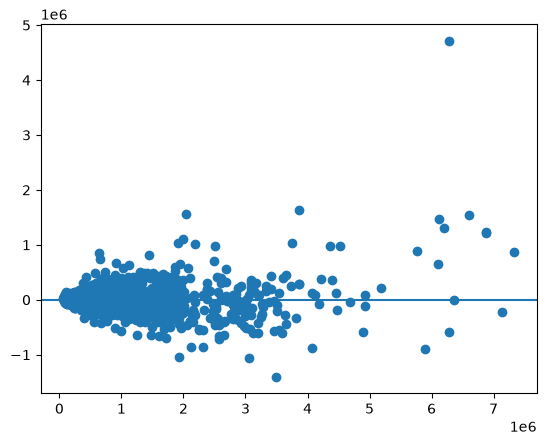

In [312]:
rmse = root_mean_squared_error(Y_test,y_pred)
print(f"RMSE: {rmse}")
residuals = Y_test - y_pred 
plt.scatter(y_pred,residuals)
plt.axhline(y=0)

In [313]:

results = pd.DataFrame({
    "actual": Y_test.values,
    "predicted": y_pred,
    "residual": residuals
}, index=Y_test.index)

results["abs_residual"] = results["residual"].abs()

top_errors = results.sort_values("abs_residual", ascending=False).head(10)

print(top_errors)

         actual     predicted      residual  abs_residual
1888   11000000  6.280392e+06  4.719608e+06  4.719608e+06
9939    5500000  3.867684e+06  1.632316e+06  1.632316e+06
7290    3600000  2.040912e+06  1.559088e+06  1.559088e+06
3410    8150000  6.598448e+06  1.551552e+06  1.551552e+06
12421   7595000  6.120906e+06  1.474094e+06  1.474094e+06
7976    2100000  3.497424e+06 -1.397424e+06  1.397424e+06
3788    7500000  6.194867e+06  1.305133e+06  1.305133e+06
12827   8100000  6.873206e+06  1.226794e+06  1.226794e+06
10403   8100000  6.877196e+06  1.222804e+06  1.222804e+06
6995    3100000  1.992071e+06  1.107929e+06  1.107929e+06


In [314]:
residual_df = pd.DataFrame({
    "predicted_price": y_pred,
    "residual": residuals
})

residual_df["absolute_residual"] = residual_df["residual"].abs()
residual_df["price_range"] = pd.cut(
    residual_df["predicted_price"],
    bins=[0, 1_000_000, 2_000_000, 3_000_000, 5_000_000, np.inf],
    labels=[
        "0-1M",
        "1M-2M",
        "2M-3M",
        "3M-5M",
        "5M+"
    ]
)
print(residual_df.groupby("price_range", observed=True)["absolute_residual"].mean())


price_range
0-1M     6.180018e+04
1M-2M    1.700486e+05
2M-3M    2.892930e+05
3M-5M    3.499670e+05
5M+      1.130702e+06
Name: absolute_residual, dtype: float64


In [315]:
X = pd.concat((X_train,X_test), axis = 0)
Y = pd.concat((Y_train,Y_test), axis = 0)
df = pd.concat((X,Y), axis = 1)


In [316]:
pipeline = Pipeline([
    ('clt',trans),
    ('model',gridmodel2)
])

In [317]:
pipeline.fit(X_train,Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('clt', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['brand','model','vehicle_age',...,'transmission_type','mileage','engine']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated wit

In [318]:
import pickle 
with open('../model/model.pkl','wb') as file:
    pickle.dump(pipeline, file)

In [319]:
unq_engine = df['engine'].unique()
unq_engine

array([1500, 3000, 1200, 1250, 1600, 2200, 1000, 2500, 1400, 2000, 1800,
        800, 2400, 1100, 2800, 1300, 2100, 2350, 2600, 3500, 1950, 1050,
       4100, 2150, 4400, 1900, 3200, 5500, 2700, 1350, 3600, 4700])

In [320]:
df['fuel_type'].value_counts()

fuel_type
Petrol              7441
Diesel              7226
Others (CNG/LPG)     345
Name: count, dtype: int64

In [321]:
for i in unq_engine:
    check = df.loc[(df['engine'] == i) & (df['fuel_type'] == 'Petrol')]
    print(f"fuel_type: Petrol, engine: {i}, max: {check['mileage'].max()}, min: {check['mileage'].min()}")
    check = df.loc[(df['engine'] == i) & (df['fuel_type'] == 'Diesel')]
    print(f"fuel_type: Diesel, engine: {i}, max: {check['mileage'].max()}, min: {check['mileage'].min()}")
    check = df.loc[(df['engine'] == i) & (df['fuel_type'] == 'Others (CNG,LPG)')]
    print(f"fuel_type: Others (CNG,LPG), engine: {i}, max: {check['mileage'].max()}, min: {check['mileage'].min()}")

fuel_type: Petrol, engine: 1500, max: 21.56, min: 12.0
fuel_type: Diesel, engine: 1500, max: 27.4, min: 14.59
fuel_type: Others (CNG,LPG), engine: 1500, max: nan, min: nan
fuel_type: Petrol, engine: 3000, max: 13.0, min: 7.81
fuel_type: Diesel, engine: 3000, max: 18.59, min: 11.0
fuel_type: Others (CNG,LPG), engine: 3000, max: nan, min: nan
fuel_type: Petrol, engine: 1200, max: 25.0, min: 15.1
fuel_type: Diesel, engine: 1200, max: 25.32, min: 22.07
fuel_type: Others (CNG,LPG), engine: 1200, max: nan, min: nan
fuel_type: Petrol, engine: 1250, max: nan, min: nan
fuel_type: Diesel, engine: 1250, max: 28.4, min: 17.8
fuel_type: Others (CNG,LPG), engine: 1250, max: nan, min: nan
fuel_type: Petrol, engine: 1600, max: 17.7, min: 13.0
fuel_type: Diesel, engine: 1600, max: 23.9, min: 15.11
fuel_type: Others (CNG,LPG), engine: 1600, max: nan, min: nan
fuel_type: Petrol, engine: 2200, max: nan, min: nan
fuel_type: Diesel, engine: 2200, max: 17.6, min: 9.0
fuel_type: Others (CNG,LPG), engine: 2200

Including model's start year in India for vehicle_age validation

In [325]:
check = df['brand'].unique()
check

<StringArray>
[   'Volkswagen',           'BMW',          'Ford',         'Honda',
         'Skoda',        'Maruti',       'Renault',       'Hyundai',
      'Mahindra',        'Jaguar',          'Jeep',        'Toyota',
        'Datsun',          'Tata', 'Mercedes-Benz',          'Audi']
Length: 16, dtype: str

In [326]:
model_years = pd.DataFrame(
    [
        ["Maruti", "Eeco", 2010],
        ["Renault", "Duster", 2012],
        ["BMW", "5", 2007],
        ["Ford", "Figo", 2010],
        ["Maruti", "Swift", 2005],
        ["Maruti", "Wagon R", 1999],
        ["Skoda", "Rapid", 2011],
        ["Maruti", "Vitara", 2007],
        ["Hyundai", "Verna", 2006],
        ["Honda", "Amaze", 2013],
        ["Ford", "Ecosport", 2013],
        ["Mahindra", "Scorpio", 2002],
        ["Jeep", "Compass", 2017],
        ["BMW", "3", 2007],
        ["Honda", "City", 1998],
        ["Hyundai", "i20", 2008],
        ["Maruti", "Swift Dzire", 2008],
        ["Mahindra", "Thar", 2010],
        ["Maruti", "Ciaz", 2014],
        ["Maruti", "Alto", 2000],
        ["Maruti", "Baleno", 2015],
        ["Tata", "Nexon", 2017],
        ["Datsun", "GO", 2014],
        ["Mahindra", "XUV500", 2011],
        ["Tata", "Hexa", 2017],
        ["Hyundai", "i10", 2007],
        ["Jaguar", "XF", 2009],
        ["Maruti", "Ertiga", 2012],
        ["Volkswagen", "Polo", 2010],
        ["Hyundai", "Grand", 2013],
        ["Toyota", "Fortuner", 2009],
        ["Volkswagen", "Vento", 2010],
        ["Toyota", "Innova", 2005],
        ["Hyundai", "Elantra", 2004],
        ["Mahindra", "KUV100", 2016],
        ["Hyundai", "Santro", 1998],
        ["Mercedes-Benz", "GL-Class", 2010],
        ["Renault", "KWID", 2015],
        ["Skoda", "Superb", 2004],
        ["Tata", "Safari", 1998],
        ["Hyundai", "Creta", 2015],
        ["Tata", "Tiago", 2016],
        ["Mercedes-Benz", "E-Class", 1996],
        ["Maruti", "Celerio", 2014],
        ["Mercedes-Benz", "C-Class", 2001],
        ["Datsun", "RediGO", 2016],
        ["Honda", "Jazz", 2009],
        ["Ford", "Endeavour", 2003],
        ["Ford", "Aspire", 2015],
        ["BMW", "7", 2002],
        ["Mahindra", "Bolero", 2000],
        ["Honda", "Civic", 2006],
        ["Honda", "WR-V", 2017],
        ["BMW", "X1", 2010],
        ["Tata", "Harrier", 2019],
        ["Toyota", "Camry", 2002],
        ["Hyundai", "Venue", 2019],
        ["Mahindra", "KUV", 2016],
        ["Audi", "A6", 2005],
        ["Maruti", "Ignis", 2017],
        ["Skoda", "Octavia", 2001],
        ["Audi", "A4", 2008],
        ["Mercedes-Benz", "S-Class", 1994],
        ["Tata", "Tigor", 2017],
        ["Ford", "Freestyle", 2018],
        ["Audi", "Q7", 2006],
        ["BMW", "X5", 2007],
        ["Mahindra", "Marazzo", 2018],
        ["BMW", "X3", 2007],
        ["Honda", "CR-V", 2003],
    ],
    columns=["brand", "model", "model_start_year"]
)

df = df.merge(
    model_years,
    on=["brand", "model"],
    how="left"
)

In [327]:
df.head()

,brand,model,vehicle_age,km_driven,fuel_type,transmission_type,mileage,engine,selling_price,model_start_year
0,Volkswagen,Polo,4,75000,Diesel,Manual,20.14,1500,590000,2010
1,BMW,5,1,15000,Diesel,Automatic,18.59,3000,5400000,2007
2,Ford,Figo,4,42267,Diesel,Manual,25.83,1500,600000,2010
3,Ford,Ecosport,6,57000,Diesel,Manual,22.70,1500,735000,2013
4,Honda,Jazz,11,42000,Petrol,Manual,16.00,1200,280000,2009


In [328]:
df['model_start_year'].isna().sum()

np.int64(0)

In [329]:
df.to_csv("../Data/preprocessedDataset.csv", index=False)